<a href="https://colab.research.google.com/github/RashiBista/practice1/blob/main/DataOverwiew.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# importing utilities
import os
import sys
from datetime import datetime

# importing data science libraries
import pandas as pd
import random as rd
import numpy as np

# importing pytorch libraries
import torch
from torch import nn
from torch import autograd
from torch.utils.data import DataLoader

# import visualization libraries
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from IPython.display import Image, display
sns.set_style('darkgrid')

# ignore potential warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
%matplotlib inline

### Check GPU availability with PyTorch

In [4]:
if torch.cuda.is_available():
    print("PyTorch: GPU is available!")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
else:
    print("PyTorch: GPU is NOT available. Running on CPU.")

PyTorch: GPU is available!
GPU Name: Tesla T4
Number of GPUs: 1


### Check GPU availability with TensorFlow (if installed)

In [5]:
try:
    import tensorflow as tf
    if tf.test.is_gpu_available():
        print("TensorFlow: GPU is available!")
        print(tf.config.list_physical_devices('GPU'))
    else:
        print("TensorFlow: GPU is NOT available. Running on CPU.")
except ImportError:
    print("TensorFlow is not installed. Skipping TensorFlow GPU check.")
except Exception as e:
    print(f"An error occurred during TensorFlow GPU check: {e}")

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


TensorFlow: GPU is available!
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
!nvidia-smi

Sun Jun 28 17:04:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P0             26W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
seed_value=123
rd.seed(seed_value) #random seed
np.random.seed(seed_value) #set numpy seed
torch.manual_seed(seed_value) # pytorch seed CPU
torch.cuda.manual_seed(seed_value) # pytorch seed GPU #if (torch.backends.cudnn.version() != None and USE_CUDA == True):

## Financial Fraud Detection Dataset from
`https://www.kaggle.com/ntnu-testimon/paysim1.`

### 1. Install the Kaggle API client

In [1]:
# Install the Kaggle API client
!pip install -q kaggle

In [8]:
os.environ["KAGGLE_API_TOKEN"] = "KGAT_303ee972212c9eb74c5e1e08a7b115dd"

In [9]:
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 130MB/s]



In [10]:
!unzip creditcardfraud.zip

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


## REVIEWING THE DATA AND CLEANING IT

In [11]:
import pandas as pd

# Load the creditcard.csv into a DataFrame
df = pd.read_csv('creditcard.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [13]:
now=datetime.utcnow().strftime('%Y%m%d : %H:%M:%S')
print('[LOG {}] Transactional dataset of {} rows and {} columns loaded'.format(now, df.shape[0], df.shape[1]))

[LOG 20260628 : 17:12:25] Transactional dataset of 284807 rows and 31 columns loaded


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [15]:
df.shape

(284807, 31)

In [16]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [18]:
df.duplicated().sum()

np.int64(1081)

In [19]:
duplicate=df.duplicated()

In [20]:
duplicate.head()

,0
0,False
1,False
2,False
3,False
4,False


In [22]:
#Usually duplicate transitions are possible but no duplication of time is possilbel
df = df.drop_duplicates()

In [23]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [26]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [28]:
(df['Amount']<0).sum()
(df['Time']<0).sum()

np.int64(0)

In [30]:
#checking the balance
df["Class"].value_counts()

,count
Class,
0,283253
1,473


In [31]:
df['Class'].value_counts(normalize=True)*100

,proportion
Class,
0,99.83329
1,0.16671


In [32]:
# checking for uniqueness
df.nunique()

,0
Time,124592
V1,275663
V2,275663
V3,275663
V4,275663
V5,275663
V6,275663
V7,275663
V8,275663
V9,275663


## DATA VISUALIZATION +OUTLIER DETECTION

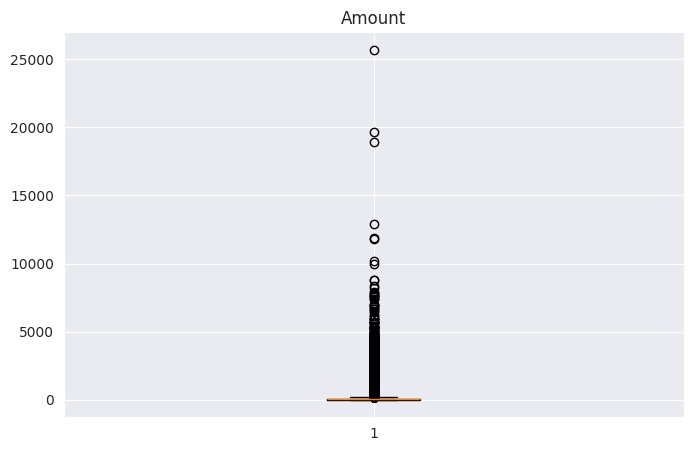

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df["Amount"])
plt.title("Amount")
plt.show()

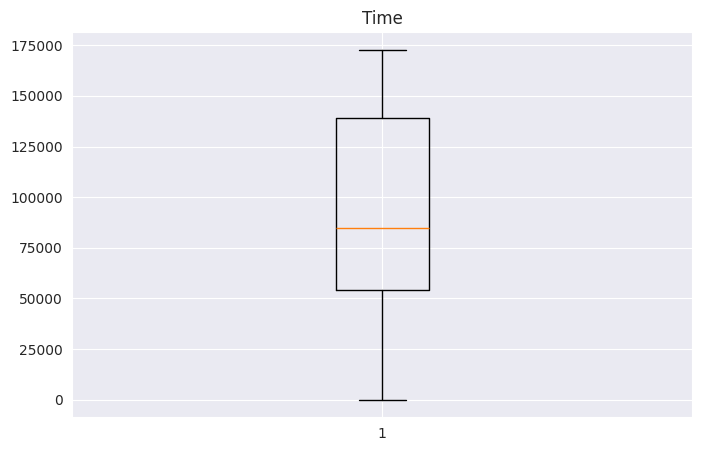

In [34]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Time"])
plt.title("Time")
plt.show()

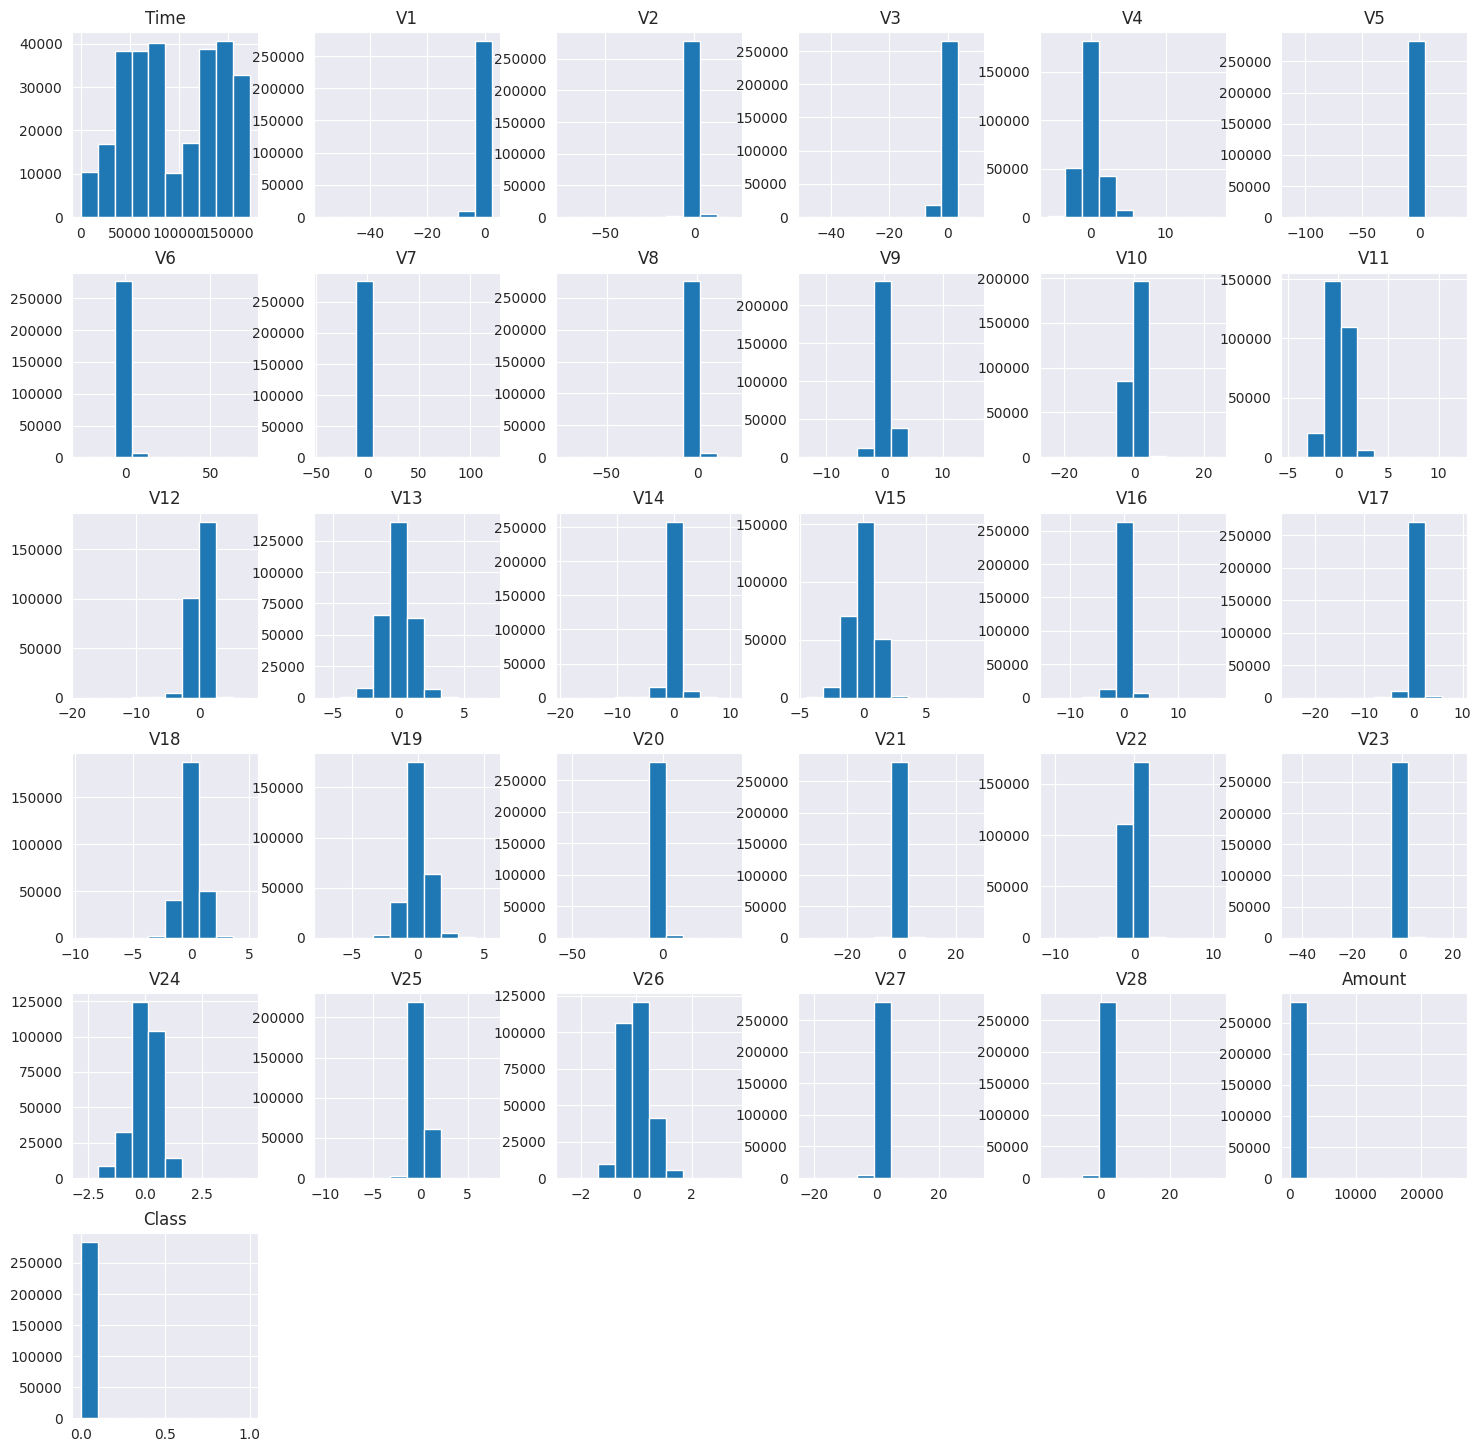

In [35]:
#checking distribution
df.hist(figsize=(18,18))
plt.show()

## SCALING

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(df[["Amount"]])

df["Time"] = scaler.fit_transform(df[["Time"]])

In [38]:
df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 

np.int64(0)

In [39]:
df.to_csv("creditcard_cleaned.csv", index=False)

In [40]:
plt.style.use("ggplot")

In [41]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,1.218105e-16,1.000002,-1.996823,-0.855213,-0.213108,0.936942,1.642362
V1,283726.0,5.917150e-03,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-4.134756e-03,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,1.613119e-03,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-2.966308e-03,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,1.827560e-03,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-1.139488e-03,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,1.800692e-03,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-8.544526e-04,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-1.596200e-03,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995


In [42]:
df["Class"].value_counts()

,count
Class,
0,283253
1,473


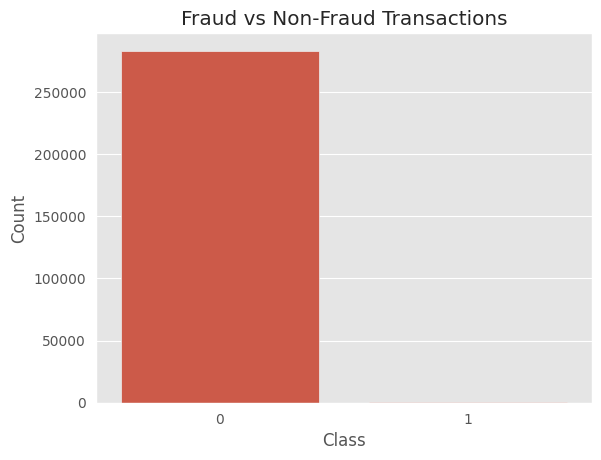

In [43]:
sns.countplot(x="Class", data=df)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [44]:
fraud_percentage = df["Class"].value_counts(normalize=True)*100
print(fraud_percentage)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


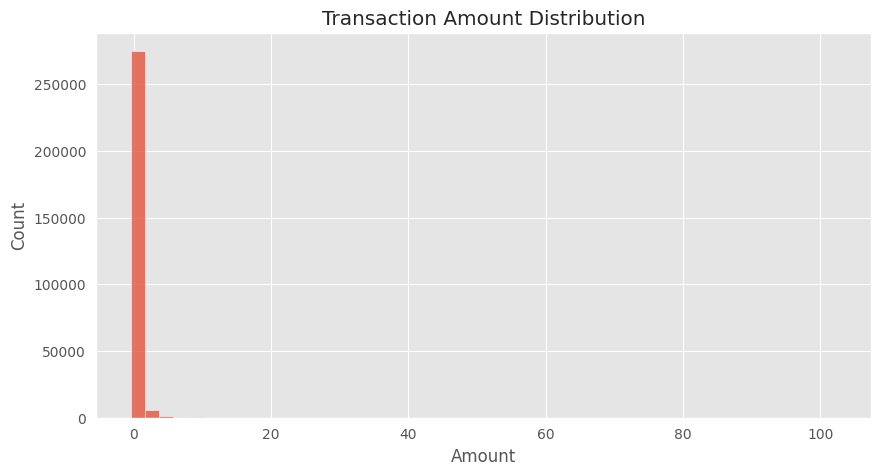

In [45]:
plt.figure(figsize=(10,5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

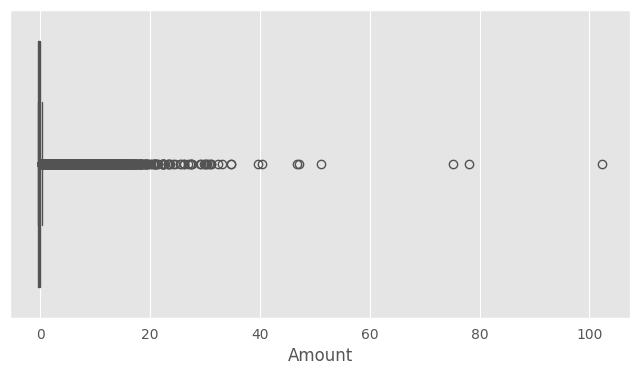

In [46]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Amount"])

plt.show()

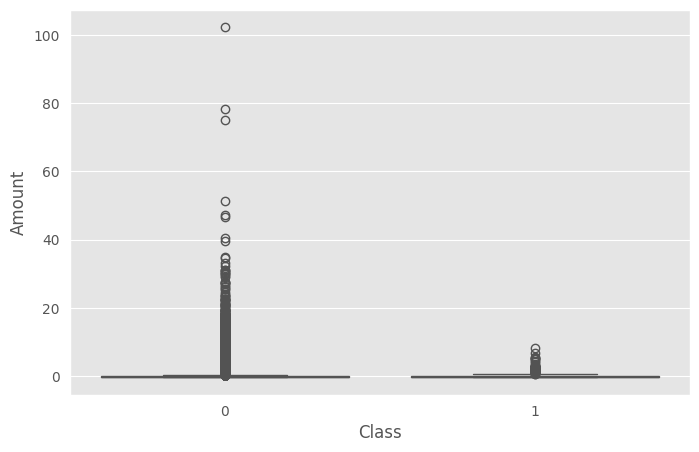

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.show()

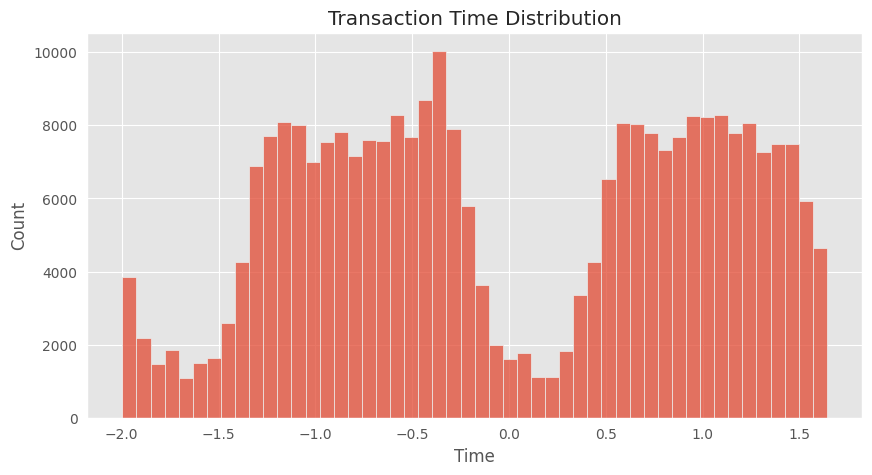

In [48]:
plt.figure(figsize=(10,5))

sns.histplot(df["Time"], bins=50)

plt.title("Transaction Time Distribution")

plt.show()

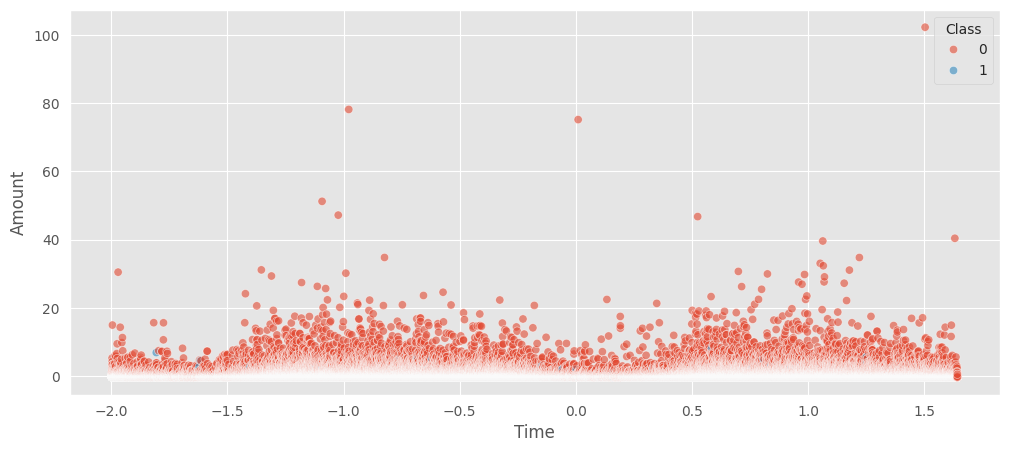

In [49]:
plt.figure(figsize=(12,5))

sns.scatterplot(
    x="Time",
    y="Amount",
    hue="Class",
    data=df,
    alpha=0.6
)

plt.show()

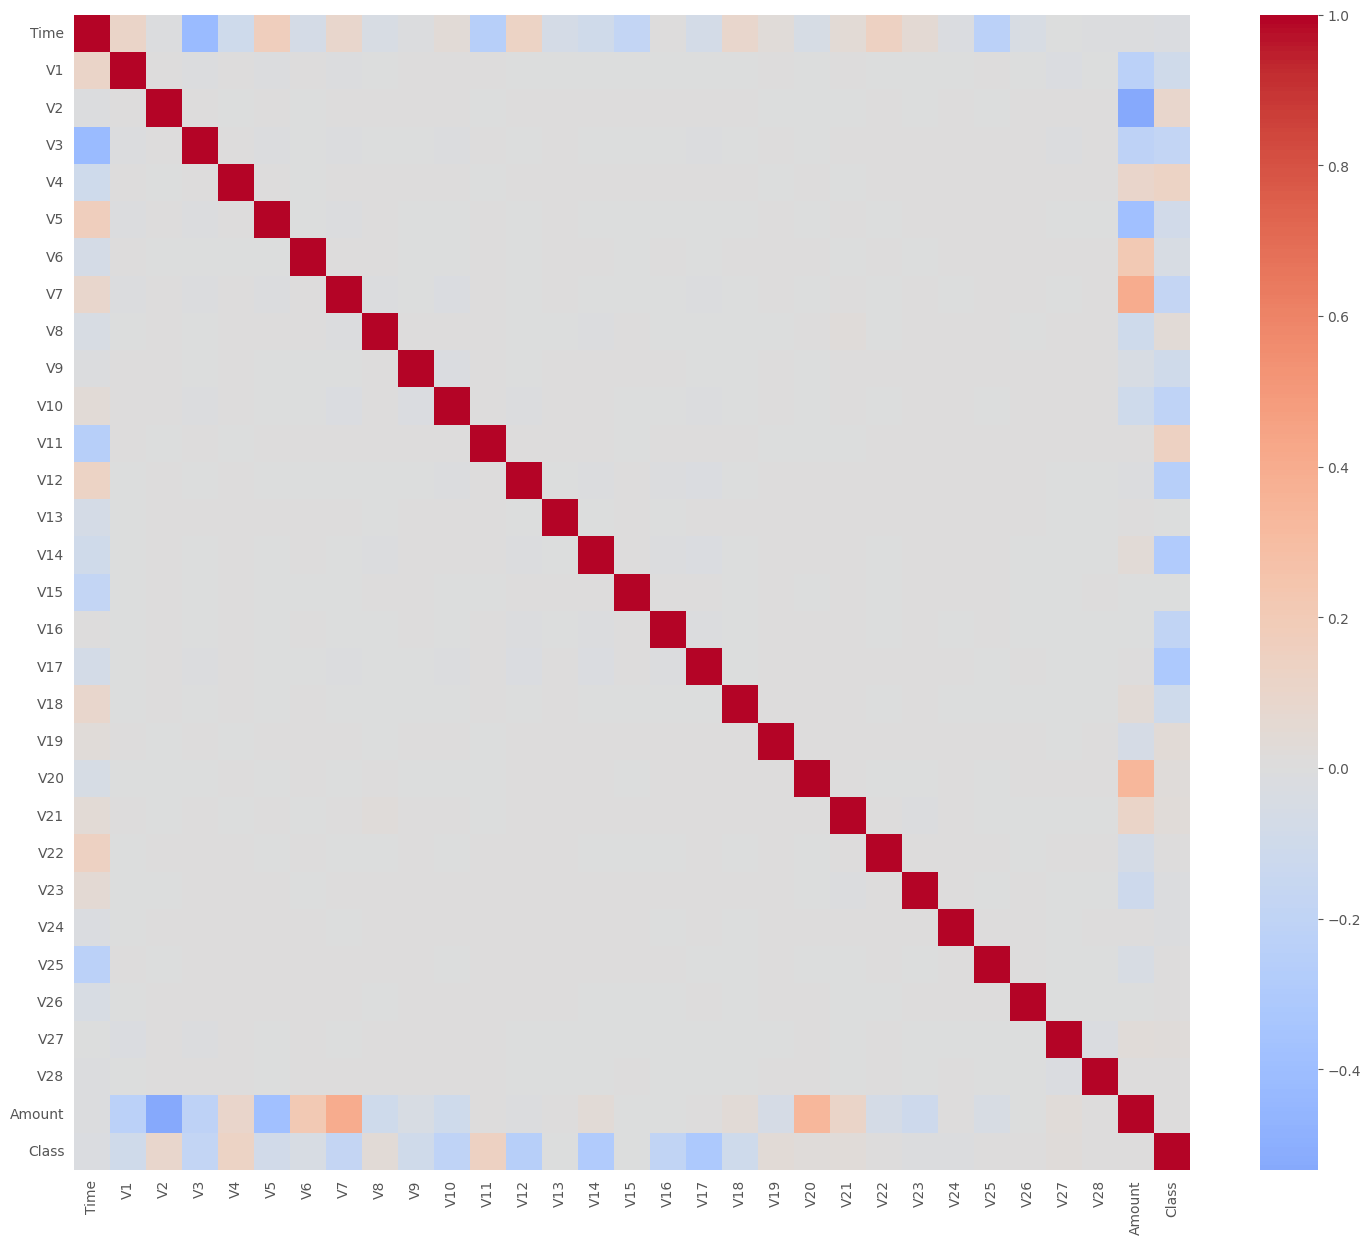

In [50]:
plt.figure(figsize=(18,15))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.show()

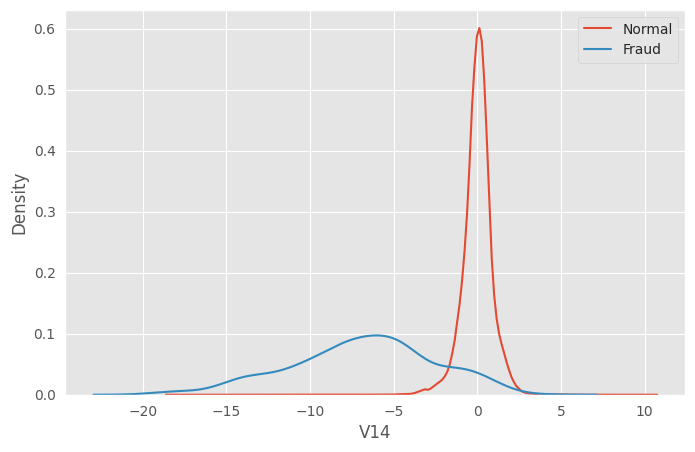

In [53]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df[df["Class"]==0],
    x="V14",
    label="Normal"
)

sns.kdeplot(
    data=df[df["Class"]==1],
    x="V14",
    label="Fraud"
)

plt.legend()

plt.show()

In [54]:
df.groupby("Class").mean().T

Class,0,1
Time,0.000505,-0.302449
V1,0.013439,-4.498280
V2,-0.009829,3.405965
V3,0.012853,-6.729599
V4,-0.010440,4.472591
V5,0.006769,-2.957197
V6,0.001251,-1.432518
V7,0.010447,-5.175912
V8,-0.002448,0.953255
V9,0.002613,-2.522124
